# PART 1 - Data Preprocessing

## Task 1: Load & Understand Dataset 
1. Load the dataset using Pandas. 
2. Print:
    -  Dataset shape
    - Column names
    - First 5 rows
    - Other essential Details
3. Identify text column(s) used for recommendations.

In [16]:
import pandas as pd
products = pd.read_csv('Data/Amazon Product Review.csv')
products.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [17]:
print("\nShape of the Data:", products.shape)
print("\Columns of the Data:", products.columns)
print("\nFirst Five rows\n", products.head())
print("\nBasic Info\n", products.info())


Shape of the Data: (1597, 27)
\Columns of the Data: Index(['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded',
       'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer',
       'manufacturerNumber', 'name', 'prices', 'reviews.date',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes',
       'upc', 'weight'],
      dtype='object')

First Five rows
                      id       asins   brand                  categories  \
0  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
1  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
2  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
3  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
4  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   

  colors             d

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Dips\AppData\Local\Temp\ipykernel_17492\3990819276.py:2: SyntaxWarning: invalid escape sequence '\C'
  print("\Columns of the Data:", products.columns)


In [18]:
#Other essental details

print("Data types:\n", products.dtypes)
print("\nMissing values:\n", products.isnull().sum())


Data types:
 id                       object
asins                    object
brand                    object
categories               object
colors                   object
dateAdded                object
dateUpdated              object
dimension                object
ean                     float64
keys                     object
manufacturer             object
manufacturerNumber       object
name                     object
prices                   object
reviews.date             object
reviews.doRecommend      object
reviews.numHelpful      float64
reviews.rating          float64
reviews.sourceURLs       object
reviews.text             object
reviews.title            object
reviews.userCity        float64
reviews.userProvince    float64
reviews.username         object
sizes                   float64
upc                     float64
weight                   object
dtype: object

Missing values:
 id                         0
asins                      0
brand                      0
cate

##### 3. Identying text column 
reviews.text → This is the main descriptive text column. It contains full product reviews written by users (long sentences, ≥10 words).

## Task 2: Text Preprocessing for Recommendation Apply the following steps on the text column:
1. Convert text to lowercase
2. Remove punctuation and special characters 
3. Remove stopwords
4. Handle missing values (replace with empty string) Store cleaned text in a new column: clean_text.

In [19]:
# 1. Convert Text to Lowercase
products['reviews.text'] = products['reviews.text'].astype(str).str.lower()


In [21]:
# 2. Remove Punctuation & Special Characters
import re
products['reviews.text'] = products['reviews.text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))


In [22]:
# 3. Remove Stopwords
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

products['clean_text'] = products['reviews.text'].apply(remove_stopwords)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dips\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
products['reviews.text'][0]

'i initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing the paperwhite is great but if you have spending money go for the voyagefortunately i had friends who owned each so i ended up buying the paperwhite on this basis both models now have  ppi so the  dollar jump turns out pricey the voyages page press isnt always sensitive and if you are fine with a specific setting you dont need auto light adjustmentits been a week and i am loving my paperwhite no regrets the touch screen is receptive and easy to use and i keep the light at a specific setting regardless of the time of day in any case its not hard to change the setting either as youll only be changing the light level at a certain time of day not every now and then while readingalso glad that i went for the international shipping option with amazon extra expense but delivery was on time with tracking and i didnt need to worry about customs which i may have if i used a th

In [24]:
products['clean_text'][0]

'initially trouble deciding paperwhite voyage reviews less said thing paperwhite great spending money go voyagefortunately friends owned ended buying paperwhite basis models ppi dollar jump turns pricey voyages page press isnt always sensitive fine specific setting dont need auto light adjustmentits week loving paperwhite regrets touch screen receptive easy use keep light specific setting regardless time day case hard change setting either youll changing light level certain time day every readingalso glad went international shipping option amazon extra expense delivery time tracking didnt need worry customs may used third party shipping service'

In [26]:
# 4. Handle Missing Values
products['clean_text'] = products['clean_text'].fillna("")

In [27]:
# Final output
print(products[['name','reviews.text','clean_text']].head())


                name                                       reviews.text  \
0  Kindle Paperwhite  i initially had trouble deciding between the p...   
1  Kindle Paperwhite  allow me to preface this with a little history...   
2  Kindle Paperwhite  i am enjoying it so far great for reading had ...   
3  Kindle Paperwhite  i bought one of the first paperwhites and have...   
4  Kindle Paperwhite  i have to say upfront  i dont like coroporate ...   

                                          clean_text  
0  initially trouble deciding paperwhite voyage r...  
1  allow preface little history casual reader own...  
2  enjoying far great reading original fire since...  
3  bought one first paperwhites pleased constant ...  
4  say upfront dont like coroporate hermetically ...  


# PART 2 - Text Vectorization

## Task 3: Vectorization using TF-IDF
1. Use TfidfVectorizer() to convert text into vectors. 
2. Set reasonable parameters:
    - max_features
    - ngram_range
3. Display:
    - Shape of TF-IDF matrix

In [30]:
# 1. Import the Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# 2.Initialize the Vectorizer with Given Parameters
vectorizer = TfidfVectorizer(
    max_features=500,       # limit vocabulary size
    ngram_range=(1,2)       # include unigrams + bigrams (1,2)
)



In [32]:
#3.Fit and Transform the Cleaned Text
tfidf_matrix = vectorizer.fit_transform(products['clean_text'])

In [33]:
# shape of matrix
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (1597, 500)


In [34]:
print("Vocabulary Sample:", list(vectorizer.get_feature_names_out()[:20]))

Vocabulary Sample: ['able', 'access', 'accurate', 'actually', 'added', 'adding', 'address', 'ads', 'alexa', 'allow', 'already', 'also', 'although', 'always', 'amazing', 'amazon', 'amazon prime', 'amazons', 'android', 'another']


## Task 4: Similarity Computation
1. Compute cosine similarity between all items. 
2. Store similarity matrix.
3. Explain briefly why cosine similarity is used.

In [35]:
# Import cosine library
from sklearn.metrics.pairwise import cosine_similarity

In [36]:
# compute similary matrix
similarity_matrix = cosine_similarity(tfidf_matrix)

In [37]:
print("Similarity Matrix Shape:", similarity_matrix.shape)

Similarity Matrix Shape: (1597, 1597)


In [38]:
print("Sample Similarities for Product 0:", similarity_matrix[0][:10])

Sample Similarities for Product 0: [1.         0.17182949 0.1924745  0.29157766 0.27956302 0.04002568
 0.17182949 0.08080629 1.         0.1924745 ]


4. Why Cosine Similarity is Used

1. Length doesn’t matter: Cosine similarity focuses on the angle between vectors, not their magnitude. So a long review and a short review can still be similar if they use similar words.

2. Captures meaning: It’s ideal for text because it measures how much two descriptions “point in the same direction” in the vector space.

3. Efficient: Works well with sparse TF‑IDF matrices and is widely used in recommendation systems.

# PART 3 - Recommendation Logic

## Task 5: Build Recommendation Function
Create a function:
    def recommend(item_name, top_n=5):
    returns top N similar items
Function should:
1. Find index of the selected item
2. Compute similarity scores
3. Sort and return top recommendations
Test with at least 3 different items.

In [48]:
products.head(2)

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight,clean_text
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,https://www.amazon.com/Kindle-Paperwhite-High-...,i initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams,initially trouble deciding paperwhite voyage r...
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,https://www.amazon.com/Kindle-Paperwhite-High-...,allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams,allow preface little history casual reader own...


In [56]:
# Drop duplicate product names
products = products.drop_duplicates(subset=['name']).reset_index(drop=True)

# Rebuild TF-IDF and similarity matrix after deduplication
tfidf_matrix = vectorizer.fit_transform(products['clean_text'])
similarity_matrix = cosine_similarity(tfidf_matrix)


In [57]:
def recommend(item_name, top_n=5):
    """
    Returns top N similar items based on cosine similarity.
    item_name: product name (string)
    top_n: number of recommendations (default = 5)
    """

    # Step 1: Find index of the selected item by name
    indices = products[products['name'] == item_name].index
    if len(indices) == 0:
        return "Item not found!"
    idx = indices[0]

    # Step 2: Compute similarity scores
    sim_scores = list(enumerate(similarity_matrix[idx]))

    # Step 3: Sort scores in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Step 4: Select top N recommendations (skip self similarity)
    top_items = sim_scores[1:top_n+1]

    # Step 5: Return product names
    recommendations = [products.iloc[i[0]]['name'] for i in top_items]
    return recommendations


In [61]:
print(recommend("Kindle Paperwhite"))
print(recommend("Amazon Echo"))
print(recommend("Nike Shoes"))


['Kindle E-reader - Black', 'Kindle Oasis with Leather Charging Cover - Black', 'Certified Refurbished Kindle E-reader', 'Kindle Voyage E-reader', 'Certified Refurbished Kindle Voyage E-reader with Special Offers']
Item not found!
Item not found!


In [60]:
print(recommend("Amazon Echo"))
print(recommend("Nike Shoes"))

Item not found!
Item not found!


# PART 5 - Version Control with Git & GitHub

## Task 7: Git & GitHub Setup 
1. Initialize a Git repository. 
2. Create a GitHub repository.
3. Push your project code to GitHub. 
- Repository must include:
    - app.py
    - requirements.txt
    - README.md

Git Clone Link : Clone Repository git clone https://github.com/DipaliKhatua/Book-Recommendation-System-With-Deployment.git

# PART 6 - - Deployment on Render

## Task 8: Deploy Application on Render 
1. Create a Render account.
2. Connect Render with GitHub.
3. Select your repository.4. Configure:
    - Build command
    - Start command
5. Deploy the application.

Live URL : https://book-recommendation-system-with.onrender.com/

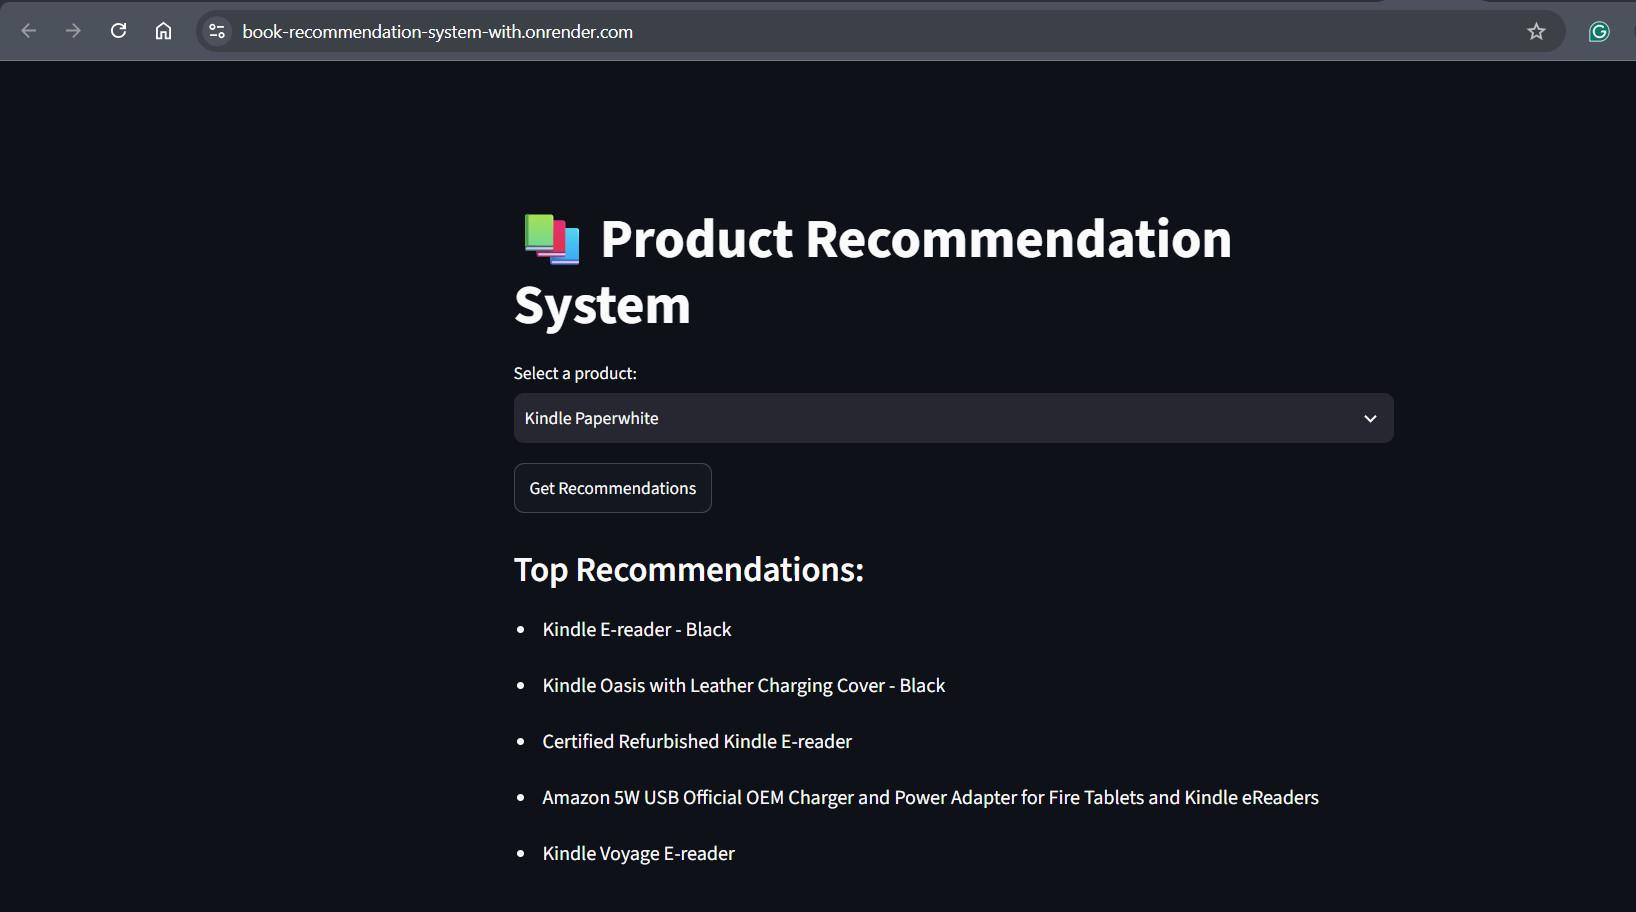